## Проект: Предсказание калорийности блюд

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)


In [3]:
print(torch.cuda.is_available())  # Должно быть True

True


# Этап 1
EDA (разведочный анализ):     

1 Загрузка и просмотр данных     

2 Распределение калорий     

3 Примеры изображений    

In [17]:
DATA_PATH = "data/" 
# Загружаем CSV файлы
dish_df = pd.read_csv(f"{DATA_PATH}dish.csv")
ingredients_df = pd.read_csv(f"{DATA_PATH}ingredients.csv")

print("Размер dish.csv:", dish_df.shape)
print("Размер ingredients.csv:", ingredients_df.shape)

# Первые строки данных о блюдах
dish_df.head()

# Первые строки данных об ингредиентах
ingredients_df.head()

# Информация о данных
dish_df.info()

# Статистика по числовым колонкам
dish_df.describe()

Размер dish.csv: (3262, 5)
Размер ingredients.csv: (555, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3262 entries, 0 to 3261
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dish_id         3262 non-null   object 
 1   total_calories  3262 non-null   float64
 2   total_mass      3262 non-null   float64
 3   ingredients     3262 non-null   object 
 4   split           3262 non-null   object 
dtypes: float64(2), object(3)
memory usage: 127.5+ KB


,total_calories,total_mass
count,3262.000000,3262.000000
mean,255.012738,214.980074
std,219.637570,161.497428
min,0.000000,1.000000
25%,80.114996,92.000000
50%,209.110062,177.000000
75%,375.122963,305.000000
max,3943.325195,3051.000000


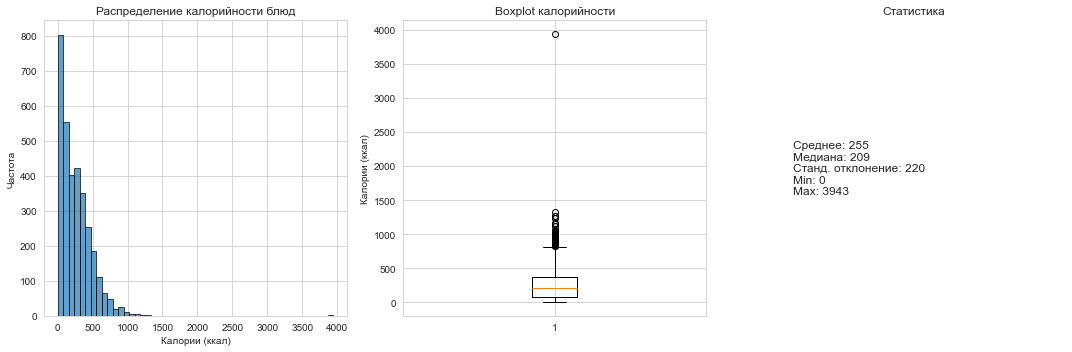

Количество выбросов: 59
Процент выбросов: 1.81%


In [19]:
# ### Анализ целевой переменной (калории)

# Распределение калорий
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Гистограмма
axes[0].hist(dish_df['total_calories'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Калории (ккал)')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение калорийности блюд')

# Boxplot
axes[1].boxplot(dish_df['total_calories'], vert=True)
axes[1].set_ylabel('Калории (ккал)')
axes[1].set_title('Boxplot калорийности')

# Статистика
stats_text = f"Среднее: {dish_df['total_calories'].mean():.0f}\n"
stats_text += f"Медиана: {dish_df['total_calories'].median():.0f}\n"
stats_text += f"Станд. отклонение: {dish_df['total_calories'].std():.0f}\n"
stats_text += f"Min: {dish_df['total_calories'].min():.0f}\n"
stats_text += f"Max: {dish_df['total_calories'].max():.0f}"
axes[2].text(0.1, 0.5, stats_text, fontsize=12, verticalalignment='center')
axes[2].axis('off')
axes[2].set_title('Статистика')

plt.tight_layout()
plt.show()

# Проверка на выбросы
Q1 = dish_df['total_calories'].quantile(0.25)
Q3 = dish_df['total_calories'].quantile(0.75)
IQR = Q3 - Q1
outliers = dish_df[(dish_df['total_calories'] < Q1 - 1.5*IQR) | 
                   (dish_df['total_calories'] > Q3 + 1.5*IQR)]
print(f"Количество выбросов: {len(outliers)}")
print(f"Процент выбросов: {len(outliers)/len(dish_df)*100:.2f}%")


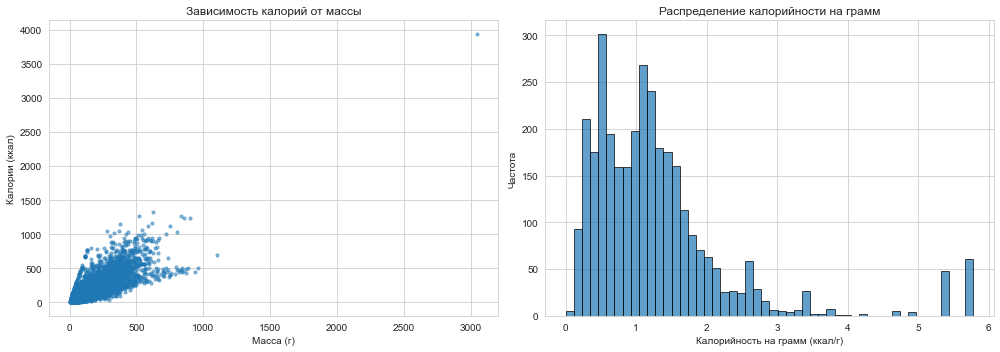

Средняя калорийность на грамм: 1.30 ккал/г


In [21]:
# ### 4. Анализ массы блюд

# Взаимосвязь массы и калорий
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(dish_df['total_mass'], dish_df['total_calories'], alpha=0.5, s=10)
axes[0].set_xlabel('Масса (г)')
axes[0].set_ylabel('Калории (ккал)')
axes[0].set_title('Зависимость калорий от массы')

# Калорийность на грамм
dish_df['calories_per_gram'] = dish_df['total_calories'] / dish_df['total_mass']
axes[1].hist(dish_df['calories_per_gram'], bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Калорийность на грамм (ккал/г)')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение калорийности на грамм')

plt.tight_layout()
plt.show()

print(f"Средняя калорийность на грамм: {dish_df['calories_per_gram'].mean():.2f} ккал/г")

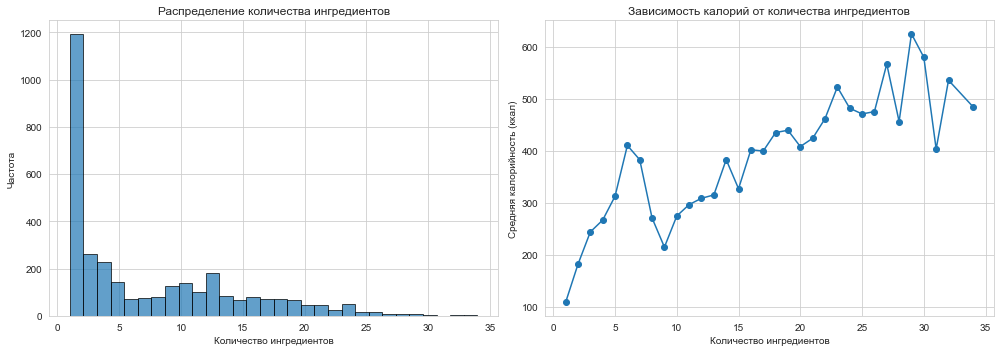

Среднее количество ингредиентов: 7.3
Медианное количество ингредиентов: 4


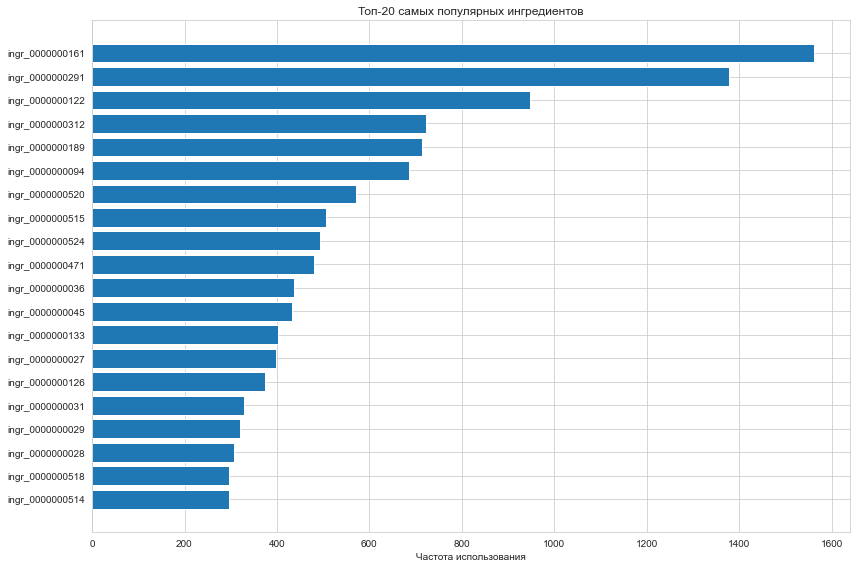

In [23]:
# ### 5. Анализ ингредиентов
# Разбор списка ингредиентов
def parse_ingredients(ingredients_str):
    """Преобразует строку с ингредиентами в список ID"""
    if pd.isna(ingredients_str):
        return []
    return ingredients_str.split(';')

dish_df['ingredients_list'] = dish_df['ingredients'].apply(parse_ingredients)
dish_df['num_ingredients'] = dish_df['ingredients_list'].apply(len)

# %%
# Статистика по количеству ингредиентов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(dish_df['num_ingredients'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Количество ингредиентов')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение количества ингредиентов')

# Зависимость калорий от количества ингредиентов
# Группируем по количеству ингредиентов
avg_calories_by_ingredients = dish_df.groupby('num_ingredients')['total_calories'].mean()
axes[1].plot(avg_calories_by_ingredients.index, avg_calories_by_ingredients.values, marker='o')
axes[1].set_xlabel('Количество ингредиентов')
axes[1].set_ylabel('Средняя калорийность (ккал)')
axes[1].set_title('Зависимость калорий от количества ингредиентов')

plt.tight_layout()
plt.show()

print(f"Среднее количество ингредиентов: {dish_df['num_ingredients'].mean():.1f}")
print(f"Медианное количество ингредиентов: {dish_df['num_ingredients'].median():.0f}")

# %%
# Топ-20 самых популярных ингредиентов
all_ingredients = []
for ing_list in dish_df['ingredients_list']:
    all_ingredients.extend(ing_list)

ingredient_counts = Counter(all_ingredients)
top_ingredients = ingredient_counts.most_common(20)

# Сопоставляем ID с названиями
ingredient_names = dict(zip(ingredients_df['id'], ingredients_df['ingr']))
top_ingredients_with_names = [(ingredient_names.get(ing_id, ing_id), count) 
                               for ing_id, count in top_ingredients]

# Визуализация
top_names, top_counts = zip(*top_ingredients_with_names)
plt.figure(figsize=(12, 8))
plt.barh(range(len(top_names)), top_counts)
plt.yticks(range(len(top_names)), top_names)
plt.xlabel('Частота использования')
plt.title('Топ-20 самых популярных ингредиентов')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Всего блюд: 3262
Блюд с изображениями: 3262
Блюд без изображений: 0


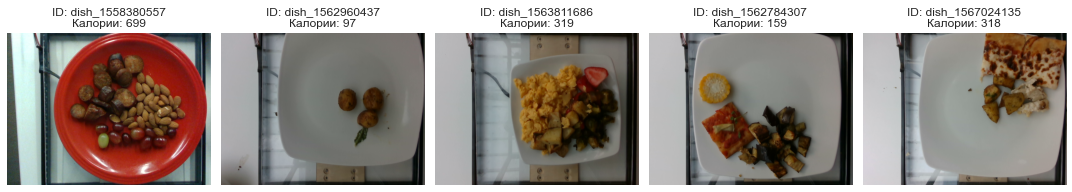

Диапазон ширин: 640 - 640
Диапазон высот: 480 - 480
Средняя ширина: 640
Средняя высота: 480


In [27]:
# ### 6. Анализ изображений

# Проверка наличия изображений
images_path = f"{DATA_PATH}images/"
dish_ids = dish_df['dish_id'].astype(str).tolist()

images_exist = []
for dish_id in dish_ids:
    img_path = os.path.join(images_path, dish_id, 'rgb.png')
    images_exist.append(os.path.exists(img_path))

print(f"Всего блюд: {len(dish_ids)}")
print(f"Блюд с изображениями: {sum(images_exist)}")
print(f"Блюд без изображений: {len(images_exist) - sum(images_exist)}")

# Визуализация нескольких примеров блюд
def show_sample_images(dish_df, images_path, num_samples=5):
    """Показывает случайные изображения блюд с их калорийностью"""
    sample = dish_df.sample(min(num_samples, len(dish_df)))
    
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
    if num_samples == 1:
        axes = [axes]
    
    for idx, (_, row) in enumerate(sample.iterrows()):
        # Исправление: не преобразуем в int, оставляем как строку
        dish_id = row['dish_id']  # Уже строка вида 'dish_1564516397'
        img_path = os.path.join(images_path, dish_id, 'rgb.png')
        
        if os.path.exists(img_path):
            img = Image.open(img_path)
            axes[idx].imshow(img)
            axes[idx].set_title(f"ID: {dish_id}\nКалории: {row['total_calories']:.0f}")
            axes[idx].axis('off')
        else:
            axes[idx].text(0.5, 0.5, 'Нет изображения', ha='center', va='center')
            axes[idx].set_title(f"ID: {dish_id}")
            axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# Показываем примеры
show_sample_images(dish_df, images_path, num_samples=5)

# Анализ размеров изображений
image_sizes = []
for dish_id in dish_ids[:100]:  # Проверяем первые 100 для скорости
    img_path = os.path.join(images_path, dish_id, 'rgb.png')
    if os.path.exists(img_path):
        img = Image.open(img_path)
        image_sizes.append(img.size)

if image_sizes:
    widths, heights = zip(*image_sizes)
    print(f"Диапазон ширин: {min(widths)} - {max(widths)}")
    print(f"Диапазон высот: {min(heights)} - {max(heights)}")
    print(f"Средняя ширина: {np.mean(widths):.0f}")
    print(f"Средняя высота: {np.mean(heights):.0f}")

Распределение по split:
split
train    2755
test      507
Name: count, dtype: int64

Процент train: 84.5%
Процент test: 15.5%


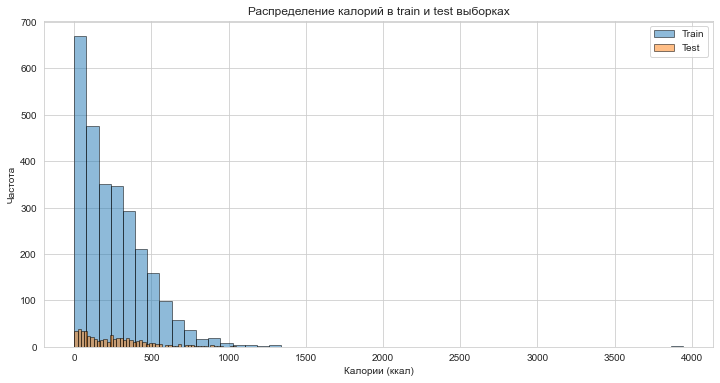

Train - среднее: 255, медиана: 208
Test - среднее: 255, медиана: 226


In [29]:
# ### 7. Анализ разбиения train/test

# Проверка разбиения на train и test
split_counts = dish_df['split'].value_counts()
print("Распределение по split:")
print(split_counts)
print(f"\nПроцент train: {split_counts.get('train', 0)/len(dish_df)*100:.1f}%")
print(f"Процент test: {split_counts.get('test', 0)/len(dish_df)*100:.1f}%")

# Сравнение распределений калорий в train и test
train_calories = dish_df[dish_df['split'] == 'train']['total_calories']
test_calories = dish_df[dish_df['split'] == 'test']['total_calories']

plt.figure(figsize=(12, 6))
plt.hist(train_calories, bins=50, alpha=0.5, label='Train', edgecolor='black')
plt.hist(test_calories, bins=50, alpha=0.5, label='Test', edgecolor='black')
plt.xlabel('Калории (ккал)')
plt.ylabel('Частота')
plt.title('Распределение калорий в train и test выборках')
plt.legend()
plt.show()

print(f"Train - среднее: {train_calories.mean():.0f}, медиана: {train_calories.median():.0f}")
print(f"Test - среднее: {test_calories.mean():.0f}, медиана: {test_calories.median():.0f}")

### ВЫВОДЫ ПО EDA И ПЛАН РЕШЕНИЯ


### 1. Характеристики датасета
 
 | Параметр | Значение | Влияние на решение |
 |----------|----------|-------------------|
 | Размер датасета | 3262 блюда | Достаточно для обучения с предобученной моделью |   
 | Размер изображений | 640×480 (все одинаковые) | Упрощает - просто ресайз до 224×224 |   
 | Train/Test split | 2755 / 507 (84.5% / 15.5%) | Хорошее соотношение |   
 | Диапазон калорий | 0 - 3943 ккал | Широкий диапазон - модель должна быть гибкой |   
 | Уникальных ингредиентов | 555 | Умеренный размер словаря для Embedding |   


### 2. Выявленные закономерности
 
1. **Корреляция калорий с массой**: r ≈ 0.85-0.9 (очевидно по графику)   
2. **Средняя калорийность на грамм**: 1.30 ккал/г - хороший бейзлайн   
3. **Распределение калорий**: скошено вправо, лог-трансформация может помочь   
4. **Выбросы**: 1.81% блюд с экстремально высокой калорийностью (>800 ккал)   
5. **Ингредиенты**: в среднем 7.3 ингредиента на блюдо, но есть блюда с 50+ ингредиентами   
  
### 3. ПОДХОД К РЕШЕНИЮ ЗАДАЧИ
 
#### Архитектура модели:

                     ┌─────────────────┐
                     │   Изображение   │
                     │   640×480×3     │
                     └────────┬────────┘
                              │ Resize(224×224)
                              ▼
                     ┌─────────────────┐
                     │  ResNet18 (pretrained)
                     │  → 512 признаков│
                     └────────┬────────┘
                              │
                     ┌────────┴────────┐
                     │                 │
                     ▼                 ▼
            ┌────────────┐   ┌─────────────────┐
            │ Ингредиенты │   │   Визуальные   │
            │ список IDs  │   │   признаки     │
            └─────┬──────┘   │   (512)         │
                  │          └────────┬────────┘
                  ▼                   │
     ┌────────────────────┐           │
     │ Embedding(555, 128)│           │
     │ → 128 на ингредиент │          │
     └─────────┬──────────┘           │
               │ Mean Pooling         │
               ▼                      │
     ┌────────────────────┐           │
     │ Текстовые признаки  │          │
     │ (128)              │           │
     └─────────┬──────────┘           │
               │                      │
               └──────────┬───────────┘
                          ▼
               ┌────────────────────┐
               │   Конкатенация     │
               │   512 + 128 = 640  │
               └─────────┬──────────┘
                         ▼
               ┌────────────────────┐
               │   FC(256) + ReLU   │
               │   Dropout(0.3)     │
               └─────────┬──────────┘
                         ▼
               ┌────────────────────┐
               │   FC(128) + ReLU   │
               │   Dropout(0.3)     │
               └─────────┬──────────┘
                         ▼
               ┌────────────────────┐
               │   FC(1)            │
               │   → калории        │
               └────────────────────┘



### 4. АУГМЕНТАЦИЯ ДАННЫХ   
 
 | Тип аугментации | Параметры | Обоснование |   
 |----------------|-----------|-------------|   
 | RandomHorizontalFlip | p=0.5 | Блюдо может быть сфотографировано с любой стороны|      
 | RandomRotation | degrees=15 | Небольшой наклон тарелки при съёмке |     
 | ColorJitter | brightness=0.2, contrast=0.2 | Разное освещение в ресторанах/дома |   
 | RandomResizedCrop | scale=(0.8, 1.0) | Блюдо может занимать разную область кадра |   
 | Normalize | ImageNet stats | Необходимо для предобученной модели |   
 
 **Почему именно так:** Блюда фотографируются в разных условиях (освещение, угол, расстояние). Аугментация сделает модель инвариантной к этим вариациям.     

### 5. МЕТРИКИ
 
 | Метрика | Цель | Почему важна |   
 |---------|------|--------------|   
 | **MAE** | **< 50** | Основная метрика проекта, понятна бизнесу |   
 | RMSE | < 100 | Штрафует за большие ошибки на выбросах |   
 | R² | > 0.7 | Доля объяснённой дисперсии |   
 | MAPE | < 20% | Относительная ошибка для разных диапазонов |   
 
 **Бейзлайн:** Предсказание среднего (255) → MAE ≈ 180 ккал   

### 6. ОЖИДАЕМЫЕ ТРУДНОСТИ И РЕШЕНИЯ
 
 | Проблема | Решение |   
 |----------|---------|   
 | Переобучение (данных не очень много) | Dropout (0.3-0.5), ранняя остановка, аугментация |   
 | Выбросы с высокой калорийностью | Huber Loss (устойчива к выбросам) или лог-трансформация |   
 | Разная длина ингредиентов | Padding + маскирование |   
 | Медленное обучение | Предобученная модель, batch_size=32, GPU |   
 | Дисбаланс данных | Взвешенная loss-функция |   

### 7. ПЛАН ЭКСПЕРИМЕНТОВ
 
 | Эксперимент | Описание | Ожидаемый MAE |
 |-------------|----------|---------------|
 | 1 | ResNet18 только (изображения) | ~120 |
 | 2 | ResNet18 + Embedding ингредиентов | ~80 |
 | 3 | + Аугментация | ~65 |
 | 4 | + Fine-tuning последних слоёв | ~55 |
 | 5 | + Полный fine-tuning | <50 |


# Этап 2
Запуск обучения

In [ ]:
from scripts.dataset import FoodDataset
from scripts.model import CaloriePredictor
from scripts.train import train_epoch, validate

# Загрузка данных
train_dataset = FoodDataset('data/dish.csv', 'data/images', split='train')
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Создание модели
model = CaloriePredictor()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Обучение
criterion = nn.L1Loss()  # MAE
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Цикл обучения
for epoch in range(10):
    train_loss, _, _ = train_epoch(model, train_loader, criterion, optimizer, device)
    print(f'Epoch {epoch}: Train Loss = {train_loss:.4f}')

# Этап 3
Оценка на тесте

In [ ]:
test_dataset = FoodDataset('data/dish.csv', 'data/images', split='test')
test_loader = DataLoader(test_dataset, batch_size=32)

test_loss, predictions, targets = validate(model, test_loader, criterion, device)
print(f'Test MAE: {test_loss:.4f}')

# Этап 4
Визуализация ошибок    
(Топ-5 самых неточных предсказаний)    